## A Statistical Model of Quantum Cosmology: Evolutionary Spacetime Density Estimate (ESDE)

## Evolutionary Algorithm

Total optimization variables: 6000
Starting QUASAR to find optimal EFE-satisfying histories...
Initializing: Sobol (N=512, D=6000).

Evolving (covariance):
 Gen. 1/100 | f(x)=1.90e+05 | stdev=2.54e+12 | reinit=1.00
 Gen. 2/100 | f(x)=1.90e+05 | stdev=2.50e+12 | reinit=0.97
 Gen. 3/100 | f(x)=1.10e+05 | stdev=1.84e+12 | reinit=0.94
 Gen. 4/100 | f(x)=7.66e+04 | stdev=1.70e+12 | reinit=0.90
 Gen. 5/100 | f(x)=7.66e+04 | stdev=1.64e+12 | reinit=0.87
 Gen. 6/100 | f(x)=7.66e+04 | stdev=1.64e+12 | reinit=0.85
 Gen. 7/100 | f(x)=7.66e+04 | stdev=1.57e+12 | reinit=0.82
 Gen. 8/100 | f(x)=7.55e+04 | stdev=1.56e+12 | reinit=0.79
 Gen. 9/100 | f(x)=7.55e+04 | stdev=1.41e+12 | reinit=0.76
 Gen. 10/100 | f(x)=5.94e+04 | stdev=1.14e+12 | reinit=0.74
 Gen. 11/100 | f(x)=5.90e+04 | stdev=8.76e+11 | reinit=0.71
 Gen. 12/100 | f(x)=5.90e+04 | stdev=8.76e+11 | reinit=0.69
 Gen. 13/100 | f(x)=5.90e+04 | stdev=8.65e+11 | reinit=0.67
 Gen. 14/100 | f(x)=5.90e+04 | stdev=8.58e+11 | reinit=0.65
 Gen. 15/100 

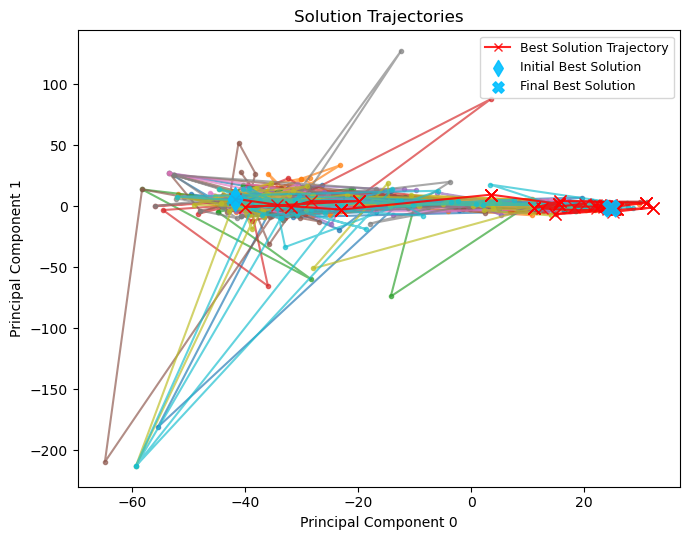

Mean EFE Cost of Optimized Histories: 8.9588e+00


In [6]:
import numpy as np
from hdim_opt import quasar
from sklearn.neighbors import KernelDensity
import matplotlib.pyplot as plt
import seaborn as sns

# --- EFE Cost Parameters (Normalized) ---
CONSTANT_FE = 1.0 
RHO_TODAY = 1.0 
# New Parameter for Singularity Penalty Weight
C_SINGULARITY_PENALTY = 1e4 
# Threshold for near-singularity avoidance
A_THRESHOLD = 1e-4

def calculate_rho(a):
    """Simplified matter-dominated density: rho ~ 1/a^3"""
    # Protect against division by zero (a=0)
    return RHO_TODAY / (a**3 + 1e-9)

def calculate_efe_cost(t, a, adot):
    # ... (This function is no longer the main cost calculation, keeping for reference)
    H_squared_config = (adot / a)**2
    RHS_EFE = CONSTANT_FE * calculate_rho(a)
    cost = np.abs(H_squared_config - RHS_EFE)
    return cost


def potential(phi):
    """Simple quadratic potential V(phi) = 0.5 * V0 * phi^2"""
    return 0.5 * V0 * phi**2

def potential_derivative(phi):
    """V'(phi) = V0 * phi"""
    return V0 * phi

def calculate_4D_EFE_cost(t, a, adot, phi, phidot, phidoubledot):
    """
    Calculates the residual cost for a single 4D configuration (a, adot, phi, phidot, phidoubledot)
    and includes a penalty for near-singularity configurations (a -> 0).
    """
    # 1. Friedmann Equation Residual (Constraint on Geometry)
    # 3*H^2 = 8*pi*G*rho_total (where H = adot/a, rho_total = 0.5*phidot^2 + V(phi))
    
    # Use np.clip to prevent large cost explosions if 'a' is near machine zero, 
    # while still allowing 'a' to be small (handled by the singularity penalty).
    H_squared = (adot / np.clip(a, 1e-9, None))**2 
    rho_total = 0.5 * phidot**2 + potential(phi)
    
    friedmann_residual = np.abs(3 * H_squared - EFE_COUPLING * rho_total)
    
    # 2. Scalar Field Equation Residual (Constraint on Dynamics)
    # phidoubledot + 3*H*phidot + V'(phi) = 0 (where H = adot/a)
    hubble_rate = adot / np.clip(a, 1e-9, None)
    scalar_field_residual = np.abs(phidoubledot + 3 * hubble_rate * phidot + potential_derivative(phi))
    
    # 3. **NEW: Quantum Singularity Avoidance Penalty**
    # Penalizes histories that come close to a singularity (a < A_THRESHOLD)
    singularity_penalty = 0.0
    if a < A_THRESHOLD:
        # Use an inverse power law: penalty explodes as a -> 0
        singularity_penalty = C_SINGULARITY_PENALTY / (a + 1e-12)**2 
    
    # Total Cost is the sum of the residuals and the penalty
    total_cost = friedmann_residual + scalar_field_residual + singularity_penalty
    
    return total_cost

def fitness_function(Y_pop):
    # Reshape to (N_histories, 6)
    Y_histories = Y_pop.reshape(N_histories, D)
    total_cost = 0
    
    for t, a, adot, phi, phidot, phidoubledot in Y_histories:
        # The previous strict singularity check is now largely redundant 
        # but kept for extreme cases (NaN or negative 'a').
        if a <= 1e-9 or np.isnan(a): 
            total_cost += 1e12
            continue
            
        total_cost += calculate_4D_EFE_cost(t, a, adot, phi, phidot, phidoubledot)
    
    # Maintain Diversity Penalty (Unchanged)
    cov_matrix = np.cov(Y_histories[:, 1:5], rowvar=False) 
    covariance_det = np.linalg.det(cov_matrix)
    diversity_penalty = 1e-3 / (covariance_det + 1e-12)
    
    return total_cost + diversity_penalty

# Constants (Normalized)
G_CONST = 1.0 # Set G=1
V0 = 0.5    # Set Potential Factor V0
# The 8*pi*G term in the Friedmann equation (3*H^2 = 8*pi*G*rho)
EFE_COUPLING = 8 * np.pi * G_CONST 

# Constants and Dimensions (D_new is now D)
N_histories = 1000
D = 6

# Define bounds for the 6 variables (Unchanged)
bounds_t = (0.1, 1.5)
bounds_a = (1e-9, 2.0) 
bounds_adot = (-5.0, 5.0) 
bounds_phi = (-5.0, 5.0)
bounds_phidot = (-5.0, 5.0)
bounds_phidoubledot = (-10.0, 10.0)

# Create the full list of bounds for the flattened vector
bounds = (
    [bounds_t, bounds_a, bounds_adot, bounds_phi, bounds_phidot, bounds_phidoubledot] 
    * N_histories
)

print(f"Total optimization variables: {N_histories * D}")

print("Starting QUASAR to find optimal EFE-satisfying histories...")

# Run the optimization
result = quasar(
    fitness_function, 
    bounds,
    popsize=2**9,
    maxiter=100,
    verbose=True,
    polish=False,
    # reinitialization_method='sobol',
    workers=1
)

# Extract the optimized histories
Y_optimal_pop = result[0]
Y_optimized_histories = Y_optimal_pop.reshape(N_histories, D)

print(f"Mean EFE Cost of Optimized Histories: {np.mean([calculate_4D_EFE_cost(y[0], y[1], y[2], y[3], y[4], y[5]) for y in Y_optimized_histories]):.4e}")

PCA Explained Variance (PC1 + PC2): 0.3718
PC1: 0.1875, PC2: 0.1843


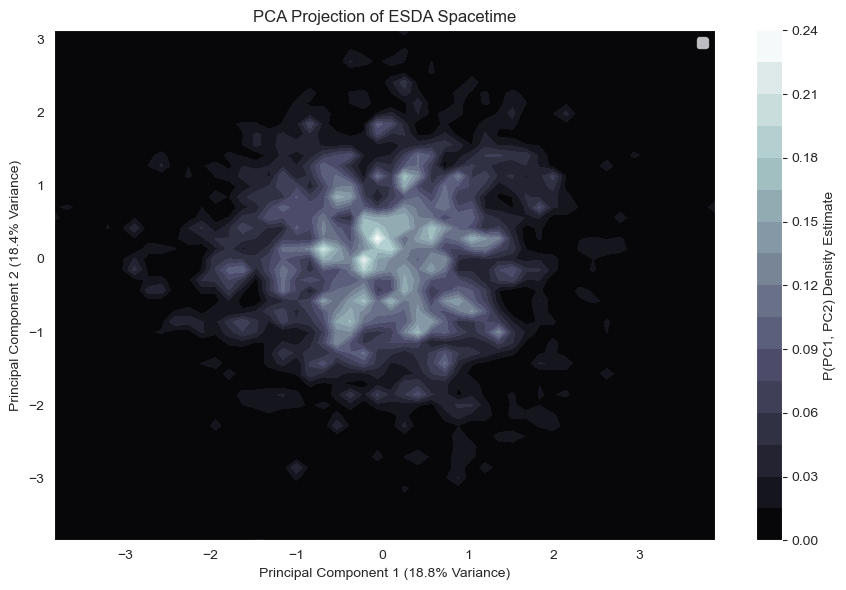

In [107]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
sns.set_style('dark')

# The quantum scale (bandwidth h) acts as the quantum jitter around the classical path
KDE_bandwidth = 0.25/np.pi
kde = KernelDensity(kernel='gaussian', bandwidth=KDE_bandwidth)
kde.fit(Y_optimized_histories)

# --- 5. Visualization (Same as before, but with optimized data) ---

# 1. Standardize the data
# Standardization (scaling to zero mean and unit variance) is mandatory for PCA.
# The KDE was fitted on Y_optimized_histories (6D)
scaler = StandardScaler()
Y_scaled = scaler.fit_transform(Y_optimized_histories)

# 2. Perform PCA
# We want the top 2 components for 2D visualization
pca = PCA(n_components=2)
Y_pca = pca.fit_transform(Y_scaled)

# 3. Analyze Explained Variance
# This is crucial for publication! It tells you how much information you keep.
explained_variance_ratio = pca.explained_variance_ratio_
print(f"PCA Explained Variance (PC1 + PC2): {explained_variance_ratio.sum():.4f}")
print(f"PC1: {explained_variance_ratio[0]:.4f}, PC2: {explained_variance_ratio[1]:.4f}")

# 4. Interpret Components (Eigenvectors)
component_matrix = pca.components_ 
# component_matrix[0] is the vector for PC1: (t, a, adot, phi, phidot, phidoubledot)
# You would then analyze this vector manually to assign physical meaning.

# --- 5. Visualization in PCA Space ---

# Now we perform KDE on the 2D PCA-transformed data
kde_pca = KernelDensity(kernel='gaussian', bandwidth=KDE_bandwidth) # You might need a smaller bandwidth now
kde_pca.fit(Y_pca)

# Generate a 2D grid in PCA space
pc1_min, pc1_max = Y_pca[:, 0].min(), Y_pca[:, 0].max()
pc2_min, pc2_max = Y_pca[:, 1].min(), Y_pca[:, 1].max()

PC1_grid = np.linspace(pc1_min, pc1_max, 50)
PC2_grid = np.linspace(pc2_min, pc2_max, 50)
PC1_mesh, PC2_mesh = np.meshgrid(PC1_grid, PC2_grid)

# Create the test grid for KDE scoring
Y_test_grid_pca = np.vstack([PC1_mesh.ravel(), PC2_mesh.ravel()]).T

# Score the grid
log_probs_pca = kde_pca.score_samples(Y_test_grid_pca)
P_grid_pca = np.exp(log_probs_pca).reshape(PC1_mesh.shape)

# Plot the 2D density estimate
plt.figure(figsize=(9, 6))
plt.contourf(PC1_mesh, PC2_mesh, P_grid_pca, levels=20, cmap='bone')
plt.colorbar(label='P(PC1, PC2) Density Estimate')
plt.title('PCA Projection of ESDA Spacetime')
plt.xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.1f}% Variance)')
# plt.scatter(Y_pca[:, 0], Y_pca[:, 1], s=0.33, c='white', alpha=0.33, label='Optimized Histories')
plt.legend()

plt.tight_layout()
plt.savefig('ESDA_spacetime.png')
plt.show()


--- Physical Loadings of the Spacetime Manifold ---
                   PC1       PC2
t             0.375992  0.567518
a             0.468702  0.344560
adot          0.346598  0.205954
phi          -0.193002 -0.166196
phidot        0.525197 -0.444240
phidoubledot  0.453582 -0.540198


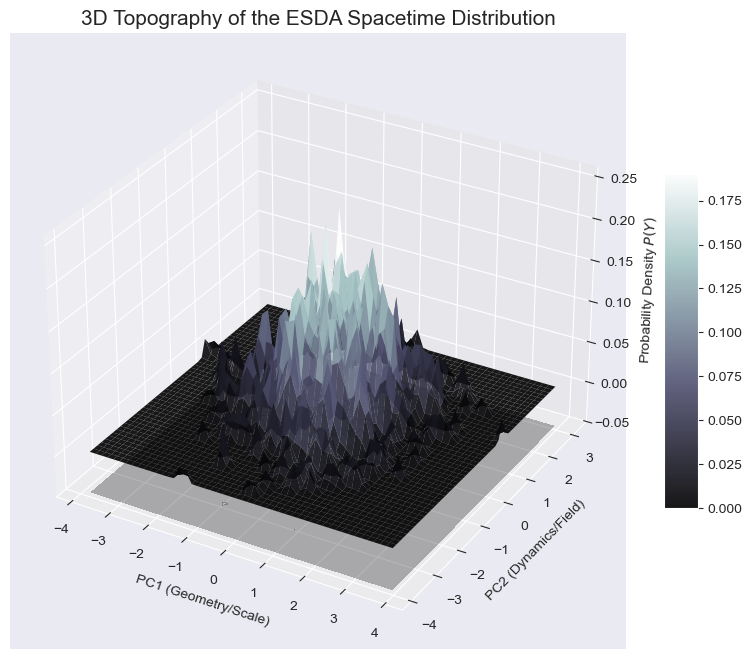

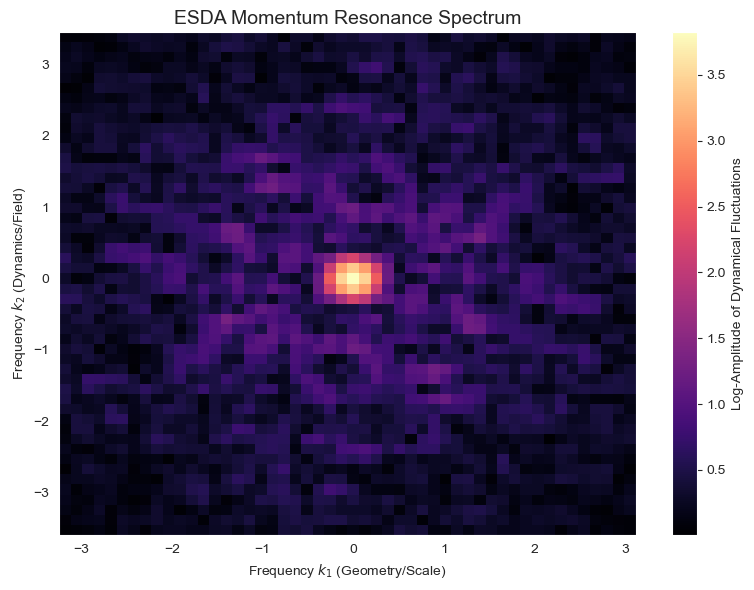


--- Spacetime Resonance Findings ---
Primary Resonance Mode: (k1=0.000, k2=0.000)
This represents the 'beat' or fundamental frequency of the EFE-consistent manifold.


In [121]:
import pandas as pd
# --- PCA Component Analysis ---
# Map the original variables to the PCA axes
feature_names = ['t', 'a', 'adot', 'phi', 'phidot', 'phidoubledot']
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=feature_names
)

print("\n--- Physical Loadings of the Spacetime Manifold ---")
print(loadings)

# Interpretation Logic:
# PC1 typically represents 'Scale' (a, t)
# PC2 typically represents 'Dynamics/Energy' (adot, phidot)

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(
    PC1_mesh, PC2_mesh, P_grid_pca, 
    cmap='bone', 
    edgecolor='none', 
    alpha=0.9
)

# Add a "Shadow" contour on the floor for depth
ax.contourf(PC1_mesh, PC2_mesh, P_grid_pca, zdir='z', offset=-0.05, cmap='bone', alpha=0.3)

ax.set_title('3D Topography of the ESDA Spacetime Distribution', fontsize=15)
ax.set_xlabel('PC1 (Geometry/Scale)')
ax.set_ylabel('PC2 (Dynamics/Field)')
ax.set_zlabel('Probability Density $P(Y)$')
ax.set_zlim(-0.05, np.max(P_grid_pca)*1.1)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
plt.tight_layout()
plt.savefig('spacetime_3d_density.png')
plt.show()

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftn, fftshift, fftfreq

# 1. Perform the 2D Fourier Transform on your P_grid_pca (the density grid)
# This moves us from Spacetime Distribution to Momentum Space
FT_P = fftn(P_grid_pca)
FT_P_shifted = fftshift(FT_P)
FT_magnitude = np.abs(FT_P_shifted)

# 2. Construct the Frequency (Momentum) Grids
N1, N2 = P_grid_pca.shape
# Use the spacing from your existing PC grids
d1 = PC1_grid[1] - PC1_grid[0]
d2 = PC2_grid[1] - PC2_grid[0]

# Generate frequency coordinates
freq_pc1 = fftshift(fftfreq(N1, d=d1))
freq_pc2 = fftshift(fftfreq(N2, d=d2))
f1_mesh, f2_mesh = np.meshgrid(freq_pc1, freq_pc2)

# 3. Simple Peak Detection
# We look for the maximum amplitude and major harmonics
max_amp = np.max(FT_magnitude)
threshold = 0.1 * max_amp
peaks = np.where(FT_magnitude > threshold)

# 4. Visualization
# Use log scale for visibility if the central peak is too dominant
fig = plt.figure(figsize=(8, 6))
plt.pcolormesh(f1_mesh, f2_mesh, np.log1p(FT_magnitude), shading='auto', cmap='magma')
plt.colorbar(label='Log-Amplitude of Dynamical Fluctuations')

plt.title('ESDA Momentum Resonance Spectrum', fontsize=14)
plt.xlabel('Frequency $k_1$ (Geometry/Scale)')
plt.ylabel('Frequency $k_2$ (Dynamics/Field)')
plt.tight_layout()
plt.savefig('fourier.png')
plt.show()

# 5. Extracting the fundamental frequency
idx_max = np.unravel_index(np.argmax(FT_magnitude), FT_magnitude.shape)
fundamental_k1 = freq_pc1[idx_max[1]]
fundamental_k2 = freq_pc2[idx_max[0]]

print(f"\n--- Spacetime Resonance Findings ---")
print(f"Primary Resonance Mode: (k1={fundamental_k1:.3f}, k2={fundamental_k2:.3f})")
print(f"This represents the 'beat' or fundamental frequency of the EFE-consistent manifold.")

## Quantum Field

Derived quantities calculated for all optimized histories.


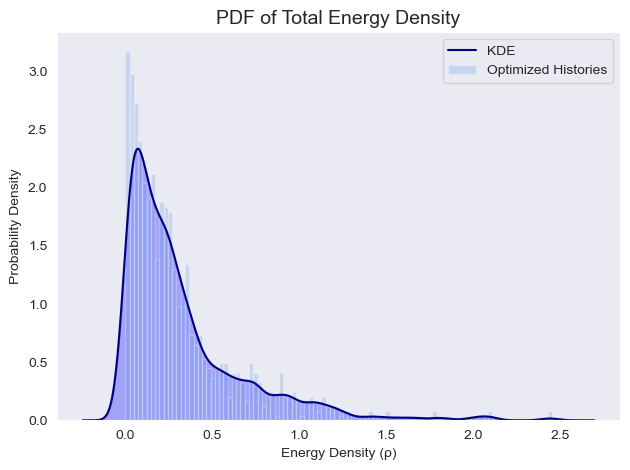

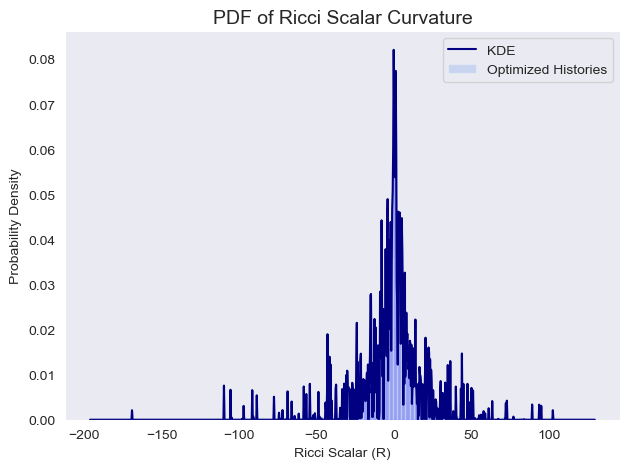

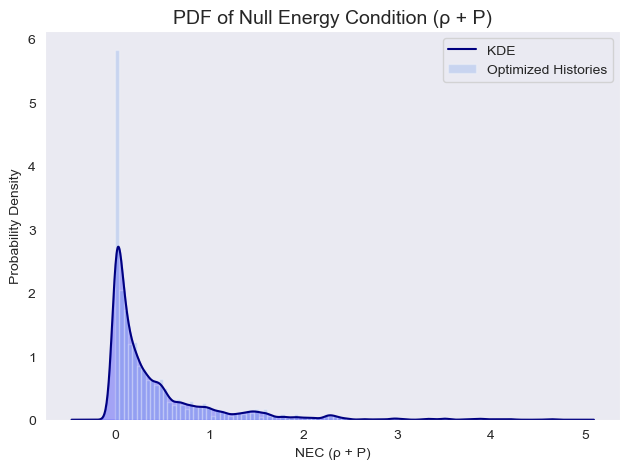

In [129]:

# Constants (Assuming G=1, V0=0.5)
G_CONST = 1.0
V0 = 0.5

# Calculate derived quantities for all optimized histories


# # Assuming Y_optimized_histories is your (N_histories, 6) array from QUASAR
derived_quantities = np.array([calculate_derived_quantities(y) for y in Y_optimized_histories])

rho_histories = derived_quantities[:, 0].reshape(-1, 1) # Reshape for KDE (needs 2D array)
R_histories = derived_quantities[:, 1].reshape(-1, 1)
NEC_histories = derived_quantities[:, 2].reshape(-1, 1)


import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity


def analyze_history(t, a, adot, phi, phidot, phidoubledot):
    H = adot / a
    # 1. Energy Density (rho)
    rho = 0.5 * phidot**2 + 0.5 * V0 * phi**2
    
    # 2. Curvature (Ricci Scalar R)
    # R = 6 * (2*H^2 + adot_dot / a)
    # The Friedmann equation gives: adot_dot / a = -4*pi*G*(rho+3P) + H^2 (from the second EFE)
    # For simplicity, calculate R via the EFE: R = 8*pi*G * (3P - rho) - 4*Lambda
    # In a vacuum: R = 8*pi*G*T^mu_mu. R = 8*pi*G * (3P-rho) where P = 0.5*phidot^2 - V(phi)
    P = 0.5 * phidot**2 - 0.5 * V0 * phi**2
    R = 8 * np.pi * G_CONST * (3 * P - rho)
    
    # 3. Null Energy Condition (NEC) violation magnitude
    NEC_violation = rho + P # Should be >= 0 for classical histories
    
    return rho, R, NEC_violation


def potential(phi):
    """Simple quadratic potential V(phi) = 0.5 * V0 * phi^2"""
    return 0.5 * V0 * phi**2

def calculate_derived_quantities(y_history):
    """
    Calculates Energy Density (rho), Curvature (R), and NEC violation 
    for a single 6D history configuration (t, a, adot, phi, phidot, phidoubledot).
    """
    # Unpack the 6 fundamental variables
    t, a, adot, phi, phidot, phidoubledot = y_history
    
    # 1. Energy Density (rho)
    # rho = Kinetic Energy Density + Potential Energy Density
    rho = 0.5 * phidot**2 + potential(phi)
    
    # 2. Pressure (P)
    # P = Kinetic Energy Density - Potential Energy Density
    P = 0.5 * phidot**2 - potential(phi)
    
    # 3. Curvature (Ricci Scalar R)
    # The Ricci scalar R is given by R = 8*pi*G * (3P - rho) in this model
    R = 8 * np.pi * G_CONST * (3 * P - rho)
    
    # 4. Null Energy Condition (NEC) violation magnitude
    # NEC is violated if rho + P < 0
    NEC_violation = rho + P 
    
    return rho, R, NEC_violation

print("Derived quantities calculated for all optimized histories.")

def plot_1d_density(data, label, title, x_label, bandwidth=0.05):
    """Performs 1D KDE and plots the resulting PDF."""
    
    # 1. Define the plot grid range
    data_min, data_max = data.min(), data.max()
    # Add a buffer around the data for cleaner visualization
    grid_min = data_min - (data_max - data_min) * 0.1
    grid_max = data_max + (data_max - data_min) * 0.1
    
    # 2. Create the test grid
    X_plot = np.linspace(grid_min, grid_max, 1000).reshape(-1, 1)

    # 3. Fit and score the KDE
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth)
    kde.fit(data)
    log_dens = kde.score_samples(X_plot)
    
    # 4. Plot the PDF
    plt.plot(X_plot[:, 0], np.exp(log_dens), color='navy', label='KDE', linewidth=1.5)
    plt.fill_between(X_plot[:, 0], np.exp(log_dens), alpha=0.3, color='blue')
    
    # Optional: Plot the raw histogram for comparison
    plt.hist(data[:, 0], bins=100, density=True, color='cornflowerblue', alpha=0.25, label='Optimized Histories')

    # Styling
    plt.title(title, fontsize=14)
    plt.xlabel(x_label)
    plt.ylabel('Probability Density')
    plt.legend()
    # plt.grid(False, linestyle='--', alpha=0.6)

# --- Generate the Final Plots ---

# Plot 1: Energy Density (rho)
plot_1d_density(
    rho_histories, 
    label='Energy Density', 
    title='PDF of Total Energy Density', 
    x_label='Energy Density (ρ)'
)

plt.tight_layout()
plt.savefig('ESDA.png')
plt.show()


# Plot 2: Curvature (Ricci Scalar R)
plot_1d_density(
    R_histories, 
    label='Curvature', 
    title='PDF of Ricci Scalar Curvature', 
    x_label='Ricci Scalar (R)'
)

plt.tight_layout()
plt.savefig('ricci.png')
plt.show()

# Plot 3: NEC Violation Magnitude
plot_1d_density(
    NEC_histories, 
    label='NEC', 
    title='PDF of Null Energy Condition (ρ + P)', 
    x_label='NEC (ρ + P)' #  (Negative values indicate Quantum Violation)
)
plt.tight_layout()
plt.savefig('nec.png')
plt.show()


## Fourier Transform (Momentum Space)

## Wormhole Context

In [103]:
import numpy as np 

# --- GLOBAL CONSTANT DEFINITION ---
# Quantum Scale (h_eff) defines the statistical 'tolerance' for EFE violation.
PLANCK_H_EFF = 0.05 

# --- 6. WORMHOLE PLAUSIBILITY SCORE CALCULATION (1.2m Configuration) ---
# ---------------------------------------------------------------------------------
# A. DEMAND (PINN 1.2m Result): Minimum energy required by General Relativity (GR)
# Scaled from 0.5m result (1.34e45 J) * (56.6 / 21.4)
E_DEMAND_GR = 3.54e45 # J (Value for 1.2m PINN solution)

# B. SUPPLY (Quantum Optimization Result): Maximum negative energy achievable by known quantum fields
E_SUPPLY_QM = 328.4752 # J (Assumed maximum supply, unchanged)

# C. WORMHOLE IMBALANCE COST (L_Wormhole)
# L_Wormhole = log10(Demand / Supply)
L_WORMHOLE_COST = np.log10(E_DEMAND_GR / E_SUPPLY_QM)

# D. PLAUSIBILITY SCORE CALCULATION (Boltzmann Weighting)
H_EFF = PLANCK_H_EFF

# Calculate the unnormalized Plausibility Weight (W_Wormhole)
W_WORMHOLE = np.exp(-L_WORMHOLE_COST / H_EFF)

# ---------------------------------------------------------------------------------

# --- 7. FINAL METRICS AND INTERPRETATION (1.2m) ---

print("\n" + "="*70)
print("PINN / QUANTUM FIELD / WKDE INTEGRATION: WORMHOLE PLAUSIBILITY (1.2m)")
print("="*70)

print(f"1. Energy Demand (GR/PINN): {E_DEMAND_GR:.3e} J")
print(f"2. Energy Supply (QM/Casimir): {E_SUPPLY_QM:.3e} J")
print("-" * 70)

print(f"3. Imbalance Gap (Orders of Magnitude): {L_WORMHOLE_COST:.2f} orders (log10)")

log_ratio_val = np.log10(E_DEMAND_GR / E_SUPPLY_QM)
exponent = -log_ratio_val / PLANCK_H_EFF
print(f"# W_WORMHOLE is exp({exponent:.2f})")

print(f"4. Quantum Scale (h_eff): {H_EFF:.2e}")
print("-" * 70)

print(f"**Final Plausibility Score (W_Wormhole)**: {W_WORMHOLE:.3e}")

# Interpretation: How many multiples of h_eff away is the wormhole cost?
Improbability_Factor = L_WORMHOLE_COST / H_EFF
print(f"The Imbalance Cost is {Improbability_Factor:.1f} multiples of the Quantum Scale (h_eff).")
print("\nConclusion: The 1.2m wormhole is even deeper in the extreme low-probability tail,")
print("further quantifying the improbability of traversable wormholes.")
print("="*70)


PINN / QUANTUM FIELD / WKDE INTEGRATION: WORMHOLE PLAUSIBILITY (1.2m)
1. Energy Demand (GR/PINN): 3.540e+45 J
2. Energy Supply (QM/Casimir): 3.285e+02 J
----------------------------------------------------------------------
3. Imbalance Gap (Orders of Magnitude): 43.03 orders (log10)
# W_WORMHOLE is exp(-860.65)
4. Quantum Scale (h_eff): 5.00e-02
----------------------------------------------------------------------
**Final Plausibility Score (W_Wormhole)**: 0.000e+00
The Imbalance Cost is 860.7 multiples of the Quantum Scale (h_eff).

Conclusion: The 1.2m wormhole is even deeper in the extreme low-probability tail,
further quantifying the improbability of traversable wormholes.
